In [ ]:
import os
import numpy as np
from time import time
from scipy.io import wavfile as wav
import matplotlib.pyplot as plt
import IPython.display as ipd # Notebook only

# Classification tools
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# File management
from google.colab import drive
import tarfile
from shutil import copyfile

# Frequency analysis
from scipy.fft import fft, fftfreq, rfft, rfftfreq
from scipy.signal import spectrogram
from librosa.feature import melspectrogram, mfcc
from librosa.display import specshow

#Data import

In [ ]:
# Link Google Drive account, transfer dataset, and extract files
drive.mount('/content/gdrive')
copyfile('gdrive/My Drive/recordings.tar', 'recordings.tar')
tar = tarfile.open('recordings.tar')
tar.extractall()
tar.close()

Mounted at /content/gdrive


In [ ]:
# Read the file 0_jackson_0.raw
sound_rate, sound_data = wav.read('recordings/0_jackson_0.wav')

# Play the signal
ipd.Audio(sound_data, rate=sound_rate)

In [ ]:
# Shape of the audio array: 5148 values, one dimension
sound_data.shape

(5148,)

In [ ]:
# Sampling rate: 8000 samples per second
sound_rate

8000

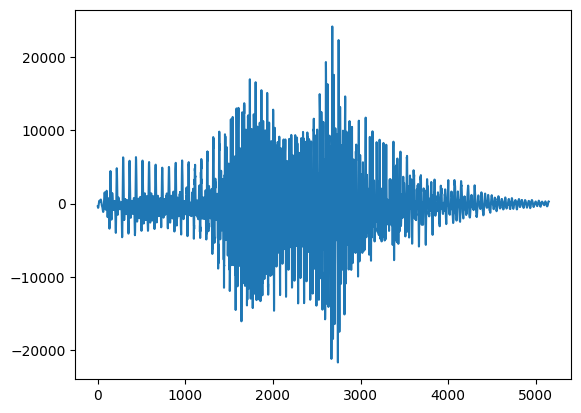

In [ ]:
# Show the signal plot
plt.plot(sound_data)

#Data loader

In [ ]:
# Placecholder for feature extractor
def identity(input):
    return input

# Data loader
def load_data(feature_extractor=identity, normalize=False):
    labels = []
    features = []
    for f in sorted(os.listdir('./recordings')):
        if f.endswith('.wav'):
            # Load file and compute the requested features
            _, signal = wav.read('./recordings/' + f)
            cur_features = feature_extractor(signal)
            features.append(cur_features)
            # Classes
            label = f.split('_')[0]
            labels.append(label)
    # X: features, y: labels
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.1, random_state=1)
    if normalize:
        eps = 0.001
        X_train = np.array(X_train)
        X_train_mean = X_train.mean(axis=0)
        X_train_std = X_train.std(axis=0)
        X_train = (X_train - X_train_mean + eps)/(X_train_std + eps)
        X_train = [row for row in X_train]
        X_test = [row for row in (np.array(X_test) - X_train_mean + eps)/(X_train_std + eps)]
    return X_train, X_test, y_train, y_test

#Features

The spectogram extracts spectral features from an input signal. It uses the Short-Time Fourier Transform (STFT) to represent how frequency components evolve over time. The outpust are:
- spec_freqs: Frequency bins.
- spec_times: Time segments.
- spec: Spectrogram matrix (magnitude of frequency components over time).

The function feats_spectogram extracts a fixed number of spectrogram columns (size) and if the spectrogram has fewer columns than size, it pads with zeros to ensure a consistent feature vector length. The matrix is then flatten into a 1D feature vector, making it compatible with machine learning models.

In [ ]:
# Define the spectogram function
def feats_spectogram(input_data, rate=8000, size=10):
  [spec_freqs, spec_times, spec] = spectrogram(input_data, fs = rate)
  # remove extra elements
  output = spec[:,0:min(size, spec.shape[1])]
  # add extra elements using pad
  output = np.pad(output, ((0,0),(0,size-output.shape[1])), 'constant')
  # unroll
  output = output.flatten()
  return output

The Mel-Frequency Cepstral Coefficients (MFCCs) represents the short-term power spectrum of a signal capturing both spectral properties and temporal dynamics of the signal.

The feats_mfcc function uses the mfcc function to compute the MFCCs from the input signal. This is done by first computing the Fourier transform of the signal, then mapping the frequencies to the Mel scale, and finally applying a Discrete Cosine Transform (DCT) to extract the coefficients.
The output is the MFCC matrix where each column represents the MFCCs for a specific time frame in the signal. Then the first tsize columns from the MFCC matrix are extracted ensuring that only the most relevant time frames are used. The output is then padded, if it's smaller than tsize, and flatten into a 1D vector by flattening it.



In [ ]:
# Define the MFCC function
def feats_mfcc(input, rate=8000, tsize=10):
    mfccs = mfcc(y=input*1.0, sr=rate)
    # remove extra elements
    output = mfccs[:,0:min(tsize, mfccs.shape[1])]
    # add extra elements using pad
    output = np.pad(output, ((0,0),(0,tsize-output.shape[1])), 'constant')
    # unroll
    output = output.flatten()
    return output

##*Spectogram*

A Support Vector Machine with kernel based on the Radial Basis Function (RBF) is used to perform the classification task. The default parameters are replaced with a search for optimal ones performed through the GridSearch method.

In [ ]:
# Data loading
X_train, X_test, y_train, y_test = load_data(feature_extractor=feats_spectogram, normalize=True)

In [ ]:
# Parameters to be tested in cross-validation
param_grid = {'C': [100, 500, 1000],
          'gamma': [0.005, 0.01, 0.1, 0.5, 1.0], }

# Support Vector Machine initialization
clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=2)

# Training
t0 = time()
clf = clf.fit(X_train, y_train)
print('Training completed in %0.3fs' % (time() - t0))

Training completed in 39.518s


In [ ]:
# Result of the cross validation for parameters selection
print('Best parameters combination:')
print(' C: '+str(clf.best_estimator_.C))
print(' gamma: '+str(clf.best_estimator_.gamma))

Best parameters combination:
 C: 1000
 gamma: 0.005


In [ ]:
# SVM test
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.59      0.69        17
           1       0.58      0.70      0.64        10
           2       0.77      0.67      0.71        15
           3       0.65      0.58      0.61        19
           4       0.30      0.27      0.29        11
           5       0.75      0.64      0.69        14
           6       0.18      0.64      0.28        14
           7       0.67      0.32      0.43        19
           8       0.80      0.24      0.36        17
           9       0.67      0.43      0.52        14

    accuracy                           0.50       150
   macro avg       0.62      0.51      0.52       150
weighted avg       0.64      0.50      0.53       150



Confusion matrix:


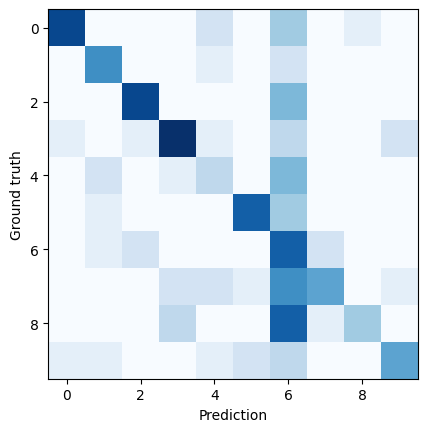

In [ ]:
# Confusion matrix
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap=plt.cm.Blues);
plt.xlabel('Prediction');
plt.ylabel('Ground truth');

The results indicate that signal classification based on the spectogram feature is actually pretty effective.  

- Accuracy of 50% indicates that the extracted features provide adeguate information.
- The majority of the classes present moderately high values of precision, recall, and F1-score suggesting that the spectogram provides sufficient information for classification.
- The fourth class present the lowest values of precision, recall and F1-score suggesting that the model failed to correctly classify lots of samples from this class.  
- The second class shows high performances, indicating that the spectogram feature may carry useful information for this class.  

##*MFCC*

A Support Vector Machine with kernel based on the Radial Basis Function (RBF) is used to perform the classification task. The default parameters are replaced with a search for optimal ones performed through the GridSearch method.

In [ ]:
# Data loading
X_train, X_test, y_train, y_test = load_data(feature_extractor=feats_mfcc, normalize=True)

/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2033
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1963
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2007
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1976
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1987
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1886
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py

In [ ]:
# Parameters to be tested in cross-validation
param_grid = {'C': [100, 500, 1000],
          'gamma': [0.005, 0.01, 0.1, 0.5, 1.0], }

# Support Vector Machine initialization
clf = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=2)

# Training
t0 = time()
clf = clf.fit(X_train, y_train)
print('Training completed in %0.3fs' % (time() - t0))

Training completed in 5.418s


In [ ]:
# Result of the cross validation for parameters selection
print('Best parameters combination:')
print(' C: '+str(clf.best_estimator_.C))
print(' gamma: '+str(clf.best_estimator_.gamma))

Best parameters combination:
 C: 100
 gamma: 0.005


In [ ]:
# SVM test
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        11
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      0.95      0.97        19
           8       1.00      1.00      1.00        17
           9       0.93      1.00      0.97        14

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



Confusion matrix:


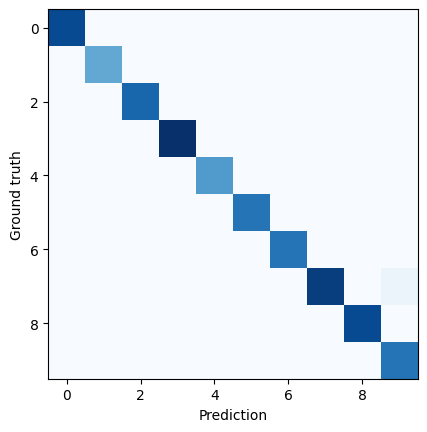

In [ ]:
# Confusion matrix
print('Confusion matrix:')
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap=plt.cm.Blues);
plt.xlabel('Prediction');
plt.ylabel('Ground truth');

The results indicate that signal classification based on the MFCC feature is actually the most effective one.  

- Accuracy of 99% indicates that the extracted feature provide almost all the necessary information to correctly classify the signals of this dataset.
- Almost all the classes present values of precision, recall, and F1-score equal to 1 suggesting that the model correctly classify almost all the samples.
- The seventh and nineth classes present the slightly lower values of recall and precision respectively suggesting that the model missclassified a few samples from these classes.  
  